In [10]:
import numpy as np
from scipy.special import wofz
from scipy.optimize import root, fsolve
from plasmapy.dispersion import plasma_dispersion_func_deriv as zprime
import matplotlib.pyplot as plt

# Numerically solving the dispersion relation of a multispecies plasma
$$1 - \frac{\omega_{p}^2}{2 \left( k v_{the} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{the}} \right) - \frac{\Omega_{1}^2}{2 \left( k v_{th_{1}} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th1}} \right) - \frac{\Omega_{2}^2}{2 \left( k v_{th 2} \right) ^2} Z^\prime \left( \frac{\omega}{\sqrt{ 2 } k v_{th 2}} \right) = 0$$

$$1 - \frac{\omega_p^2}{n_{e0} k^2} \int_{-\infty}^{\infty} dv \, \frac{\partial_v f_{e0} - \delta_1 \partial_v f_{10} - \delta_2 \partial_v f_{20}}{v - \omega / k}=0$$

## Simplifications
- I take $c=\omega_{pe}=v_{the}=n_{e0}=m_e=1$ and introduce normalized quantities $\bar{k} = k / k_D, \bar{\omega} = \omega / \omega_{pe}$

## Simple case with only electrons
$$1 - \frac{1}{2 \bar{k}^2} Z^\prime \left( \frac{\bar{\omega}}{\sqrt{2} \bar{k}} \right) = 0$$

In [55]:
def e_dielectric(wb_r, wb_i, kb):
    # wb is the frequency normalized to the electron plasma frequency
    wb = wb_r + 1j * wb_i
    return 1 - zprime(wb/(2**0.5*kb))/(2*kb*kb)

def two_ion_dielectric(

kbkb = np.linspace(0, 10, 512)
wbwb = np.zeros_like(kbkb)
for i in range(len(kbkb)):
    guess_wr = np.sqrt(1+3*kbkb[i]*kbkb[i])
    def helper(wb):
        wb_r, wb_i = wb
        d = e_dielectric(wb_r, wb_i, kbkb[i])
        return [d.real, d.imag]
    sol = root(helper, (guess_wr, 0))
    wbwb[i] = sol.x[0] + 1j * sol.x[1]

/tmp/ipykernel_3374517/2737755007.py:4: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - zprime(wb/(2**0.5*kb))/(2*kb*kb)
/tmp/ipykernel_3374517/2737755007.py:4: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - zprime(wb/(2**0.5*kb))/(2*kb*kb)
/tmp/ipykernel_3374517/2737755007.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  wbwb[i] = sol.x[0] + 1j * sol.x[1]


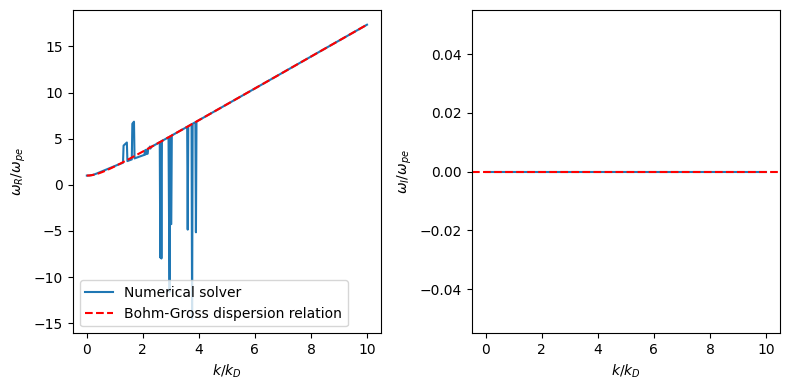

In [56]:
fig, (ax_r, ax_i) = plt.subplots(1, 2, figsize=(8,4))

ax_r.plot(kbkb, np.real(wbwb), label='Numerical solver')
ax_r.plot(kbkb, np.sqrt(1+3*kbkb**2), ls='--', color='r', label='Bohm-Gross dispersion relation')
ax_r.legend()
ax_r.set_xlabel(r'$k / k_D$')
ax_r.set_ylabel(r'$\omega_R/\omega_{pe}$')

ax_i.plot(kbkb, np.imag(wbwb))
ax_i.set_xlabel(r'$k / k_D$')
ax_i.set_ylabel(r'$\omega_I/\omega_{pe}$')
# ax_i.axhline(0, ls='--', color='r')


fig.tight_layout()

## Adding in ion contributions
- Some more notation to simplify numerics:
    - $\delta_s = \sqrt{\frac{m_e}{m_s}}$
    - $\varepsilon_s = \sqrt{\frac{n_{s0}}{n_{e0}}}$
    - $\frac{\Omega_s^2}{\omega_{pe}^2} = \delta_s^2 \varepsilon_s^2$
    - $\frac{v_s^2}{v_{the}^2} = \delta_s^2 \frac{T_s}{T_e}$

Resulting in
$$1 - \frac{1}{2 \bar{k}^2} Z^\prime \left( \frac{\bar{\omega}}{\sqrt{2} \bar{k}} \right) - \frac{\varepsilon_1^2 T_e}{2 T_1 \bar{k}^2} Z^\prime \left(\sqrt{\frac{T_e}{2T_1 \delta_1^2}}\frac{\bar{\omega}}{\bar{k}} \right) - \frac{\varepsilon_1^2 T_e}{2 T_2 \bar{k}^2} Z^\prime \left(\sqrt{\frac{T_e}{2T_2 \delta_2^2}}\frac{\bar{\omega}}{\bar{k}} \right)= 0$$

In [58]:
d1 = np.sqrt(1 / 1836)
d2 = np.sqrt(1 / 1836)
e1 = np.sqrt(0.5)
e2 = np.sqrt(0.01)
Te = 1.
T1 = 0.4
T2 = 0.3

def two_ion_dielectric(wb_r, wb_i, kb, d1, d2, e1, e2, T1, T2, Te):
    wb = wb_r + 1j * wb_i
    electron_term = zprime(wb/(2**0.5*kb))/(2*kb*kb)
    ion1_term = (e1*e1*Te)/(2*T1*kb*kb) * zprime(np.sqrt(Te/(2*T1*d1*d1)) * wb/kb)
    ion2_term = (e2*e2*Te)/(2*T2*kb*kb) * zprime(np.sqrt(Te/(2*T2*d2*d2)) * wb/kb)
    return 1 - electron_term - ion1_term - ion2_term

kbkb = np.linspace(0, 10, 512)
wbwb = np.zeros_like(kbkb)
for i in range(len(kbkb)):
    guess_wr = np.sqrt(1+3*kbkb[i]*kbkb[i])
    def helper(wb):
        wb_r, wb_i = wb
        d = two_ion_dielectric(wb_r, wb_i, kbkb[i], d1, d2, e1, e2, T1, T2, Te)
        return [d.real, d.imag]
    sol = root(helper, (guess_wr, 0))
    wbwb[i] = sol.x[0] + 1j * sol.x[1]

/tmp/ipykernel_3374517/3715859673.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  electron_term = zprime(wb/(2**0.5*kb))/(2*kb*kb)
/tmp/ipykernel_3374517/3715859673.py:11: RuntimeWarning: invalid value encountered in scalar divide
  electron_term = zprime(wb/(2**0.5*kb))/(2*kb*kb)
/tmp/ipykernel_3374517/3715859673.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  ion1_term = (e1*e1*Te)/(2*T1*kb*kb) * zprime(np.sqrt(Te/(2*T1*d1*d1)) * wb/kb)
/tmp/ipykernel_3374517/3715859673.py:12: RuntimeWarning: invalid value encountered in scalar divide
  ion1_term = (e1*e1*Te)/(2*T1*kb*kb) * zprime(np.sqrt(Te/(2*T1*d1*d1)) * wb/kb)
/tmp/ipykernel_3374517/3715859673.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  ion2_term = (e2*e2*Te)/(2*T2*kb*kb) * zprime(np.sqrt(Te/(2*T2*d2*d2)) * wb/kb)
/tmp/ipykernel_3374517/3715859673.py:13: RuntimeWarning: invalid value encountered in scalar divide
  ion2_term = (e2*e2*Te)/(2*T2*kb*kb) * zprime(np.sq

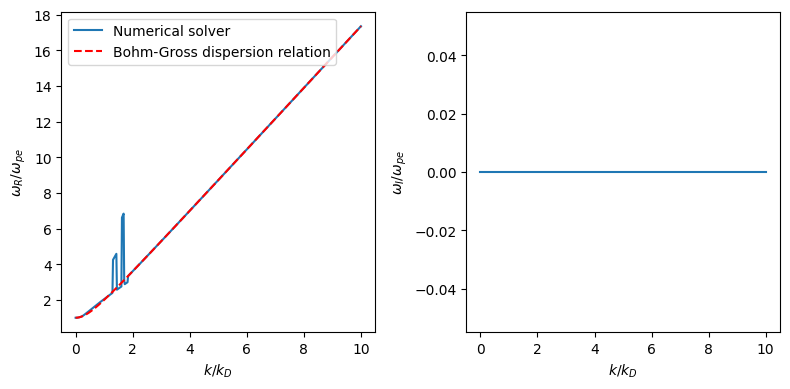

In [59]:
fig, (ax_r, ax_i) = plt.subplots(1, 2, figsize=(8,4))

ax_r.plot(kbkb, np.real(wbwb), label='Numerical solver')
ax_r.plot(kbkb, np.sqrt(1+3*kbkb**2), ls='--', color='r', label='Bohm-Gross dispersion relation')
ax_r.legend()
ax_r.set_xlabel(r'$k / k_D$')
ax_r.set_ylabel(r'$\omega_R/\omega_{pe}$')

ax_i.plot(kbkb, np.imag(wbwb))
ax_i.set_xlabel(r'$k / k_D$')
ax_i.set_ylabel(r'$\omega_I/\omega_{pe}$')
# ax_i.axhline(0, ls='--', color='r')


fig.tight_layout()